# Small Project: Predicting Airbnb Prices in NYC

## Objective
The goal of this project is to build a machine learning model to predict the price of Airbnb listings in New York City based on various features such as location, room type, and reviews.

## Dataset
You will be using the `AB_NYC_2019.csv` dataset. This dataset includes information about Airbnb listings including:
- `name`, `host_name`: Identifiers
- `neighbourhood_group`, `neighbourhood`: Location info
- `latitude`, `longitude`: Geolocation
- `room_type`: Type of accommodation
- `price`: The target variable
- `minimum_nights`, `number_of_reviews`, `reviews_per_month`, `calculated_host_listings_count`, `availability_365`: Numerical features

## Task Overview
1. **Exploratory Data Analysis (EDA)**: Understand the data distribution and relationships.
2. **Data Preprocessing**: Handle missing values, encode categorical variables, and split data.
3. **Model Building**: Train at least 3 distinct models.
4. **Evaluation**: Compare models using appropriate metrics.
5. **Analysis**: Explain your model choice and suggest improvements.

## 1. Exploratory Data Analysis (EDA)

**Tasks:**
1. Load the dataset (`AB_NYC_2019.csv`).
2. Inspect the data structure and specificities.
3. Check for missing values.
4. Visualize the distribution of the target variable `price`.
5. Visualize relationships between features and the target variable.
6. Perform any other necessary EDA to understand the dataset.

In [152]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

#### 1.1 Loading the dataset

In [17]:
df = pd.read_csv("AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


#### 1.2 Inspecting the data structure and specificities

In [18]:
df.shape


(48895, 16)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [20]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [21]:
df["room_type"].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

In [22]:
df["neighbourhood_group"].value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

In [23]:
df["neighbourhood"].value_counts()

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
                      ... 
Fort Wadsworth           1
Richmondtown             1
New Dorp                 1
Rossville                1
Willowbrook              1
Name: count, Length: 221, dtype: int64

#### 1.3 Missing values analysis

In [24]:
missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": df.isnull().mean() * 100
})

missing_df = missing_df[missing_df["Missing Values"] > 0]
missing_df = missing_df.sort_values(by="Missing Values", ascending=False)

print("📌 Missing Values Table:")
display(missing_df)

📌 Missing Values Table:


,Missing Values,Percentage (%)
last_review,10052,20.558339
reviews_per_month,10052,20.558339
host_name,21,0.042949
name,16,0.032723


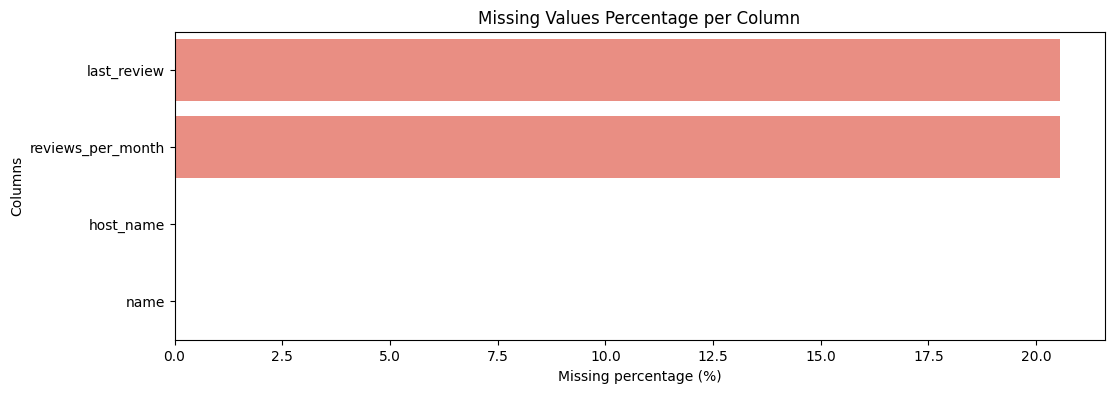

In [124]:
missing_percent = (df.isnull().mean() * 100)
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

plt.figure(figsize=(12,4))
sns.barplot(x=missing_percent.values, y=missing_percent.index, color="salmon")

plt.title("Missing Values Percentage per Column")
plt.xlabel("Missing percentage (%)")
plt.ylabel("Columns")
plt.show()

#### 1.4 Distribution of target variable (price)

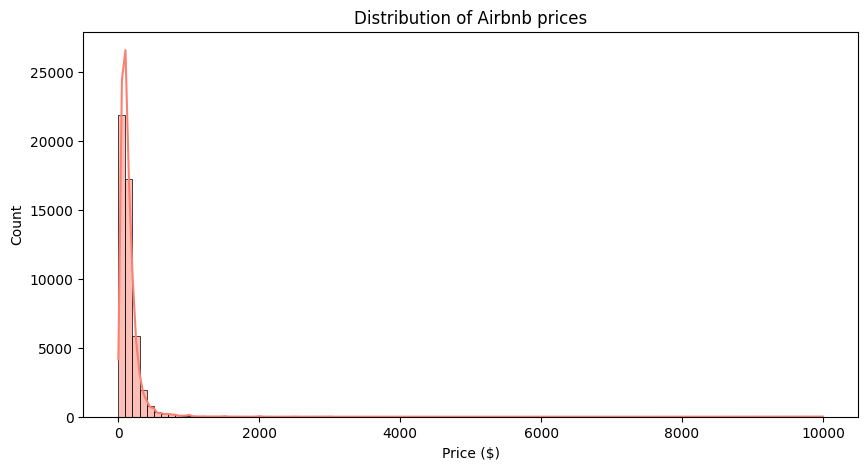

In [37]:
plt.figure(figsize=(10,5))
sns.histplot(df["price"], bins=100, kde=True, color="salmon")
plt.title("Distribution of Airbnb prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

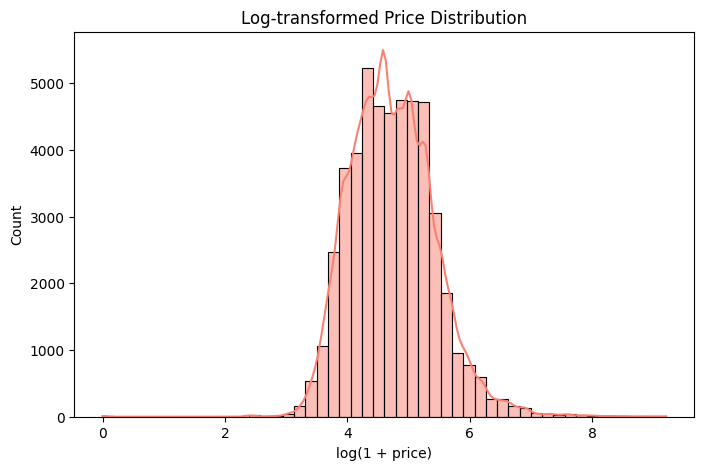

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(np.log1p(df["price"]), bins=50, kde=True, color="salmon")

plt.title("Log-transformed Price Distribution")
plt.xlabel("log(1 + price)")
plt.ylabel("Count")
plt.show()

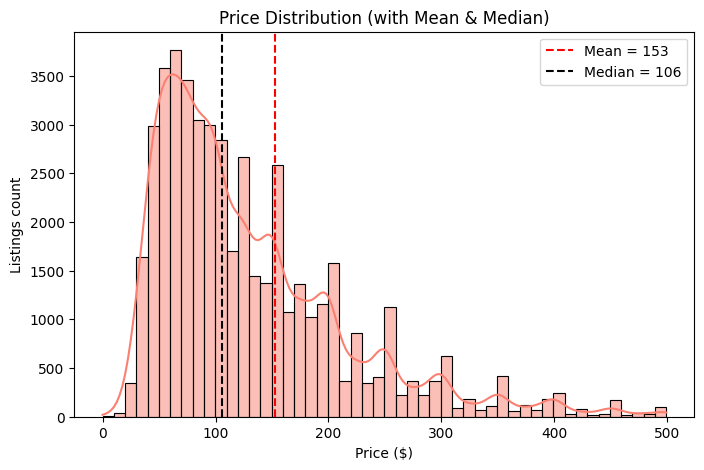

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(df[df["price"] < 500]["price"], bins=50, kde=True, color="salmon")

mean_price = df["price"].mean()
median_price = df["price"].median()

plt.axvline(mean_price, color="red", linestyle="--", label=f"Mean = {mean_price:.0f}")
plt.axvline(median_price, color="black", linestyle="--", label=f"Median = {median_price:.0f}")

plt.title("Price Distribution (with Mean & Median)")
plt.xlabel("Price ($)")
plt.ylabel("Listings count")
plt.legend()
plt.show()

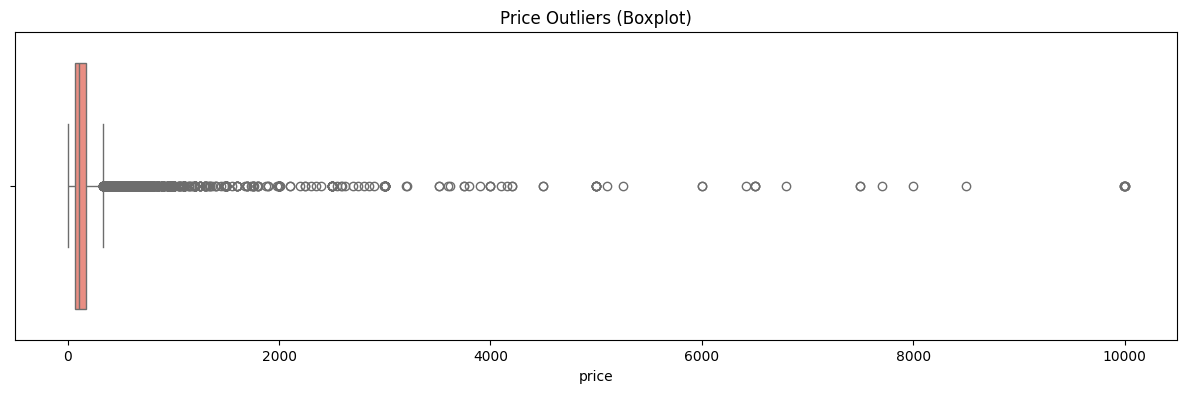

In [43]:
plt.figure(figsize=(15,4))
sns.boxplot(x=df["price"], color="salmon")
plt.title("Price Outliers (Boxplot)")
plt.show()

#### Observations (Target Variable: Price)

- The distribution of Airbnb prices is highly right-skewed, meaning that most listings have relatively low prices, while a small number of accommodations are extremely expensive.

- The majority of prices are concentrated below $500 per night, which represents the typical range for most rentals in New York City.

- Several strong outliers are present, with maximum prices reaching up to $10,000, which significantly stretches the scale of the raw distribution.

- The mean price (153) is higher than the median (106), confirming the presence of expensive listings that shift the average upward.

- After applying a log-transformation, the price distribution becomes much closer to a normal shape, which may be beneficial for building more stable regression models.

- The boxplot clearly highlights the existence of numerous outliers, suggesting that additional preprocessing steps (such as outlier handling or transformation) may be necessary before model training.

#### 1.5 Relationship between features and price

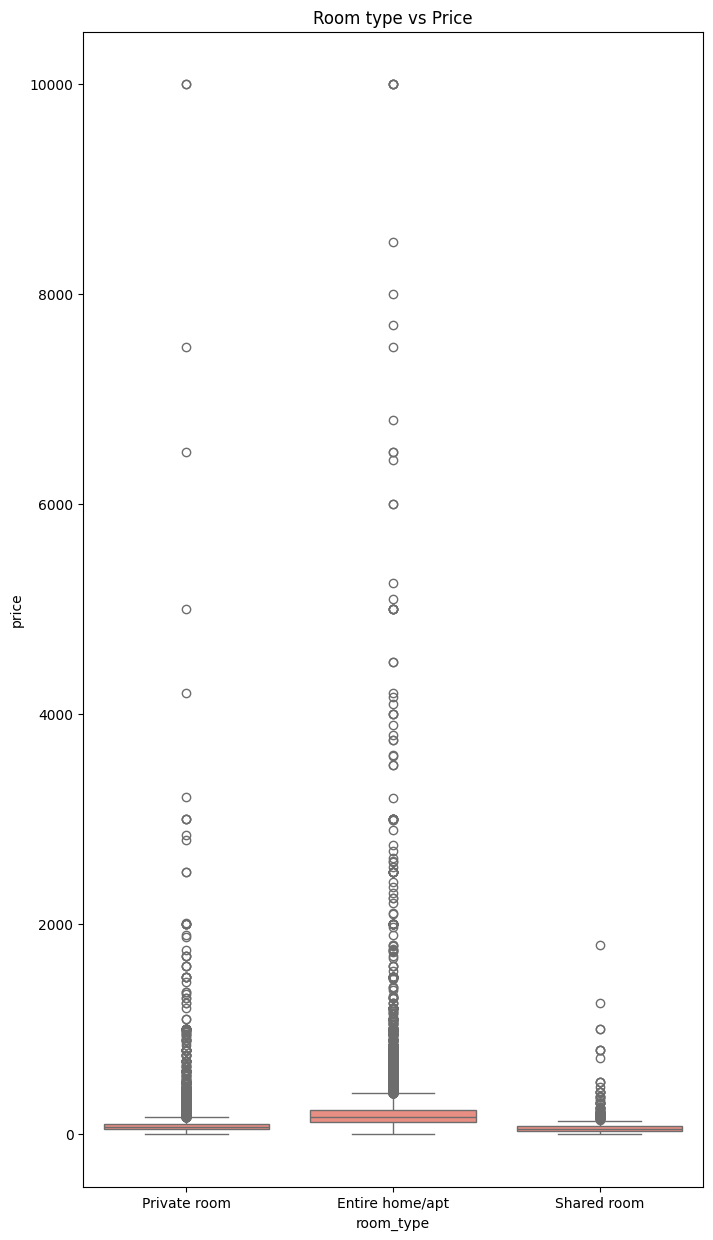

In [47]:
plt.figure(figsize=(8,15))
sns.boxplot(data=df, x="room_type", y="price", color="salmon")
plt.title("Room type vs Price")
plt.show()

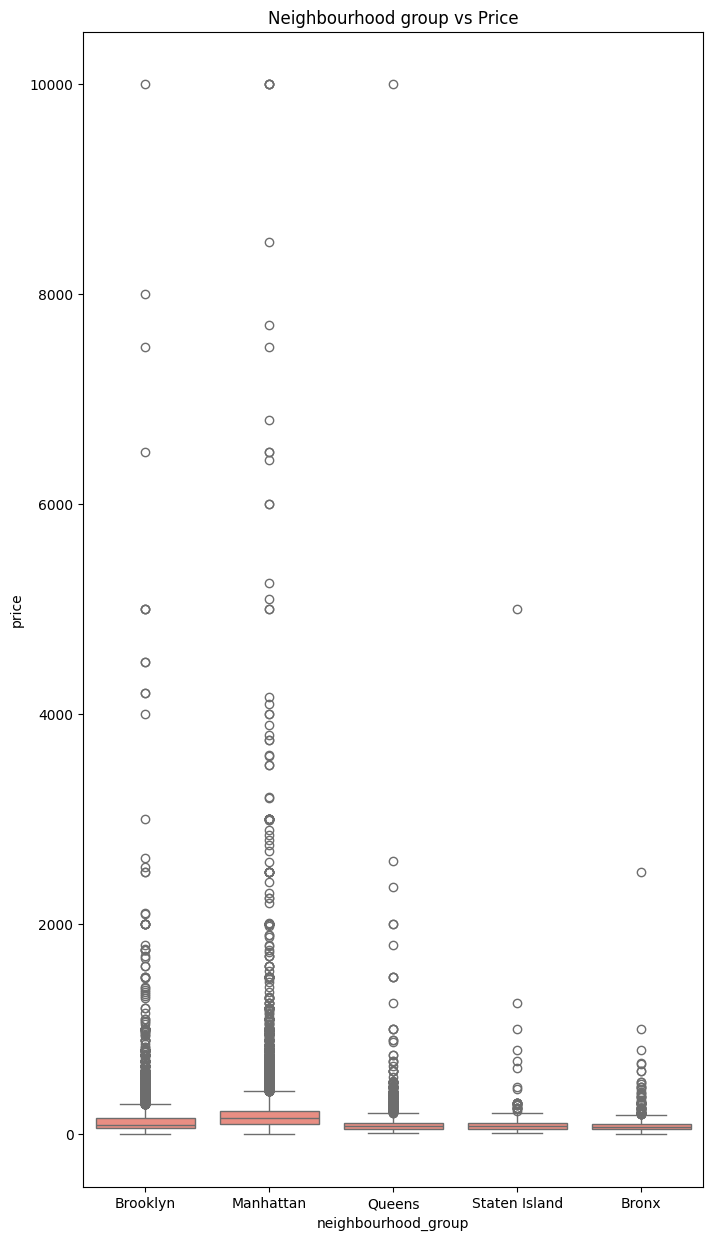

In [58]:
plt.figure(figsize=(8,15))
sns.boxplot(data=df, x="neighbourhood_group", y="price", color="salmon")
plt.title("Neighbourhood group vs Price")
plt.show()

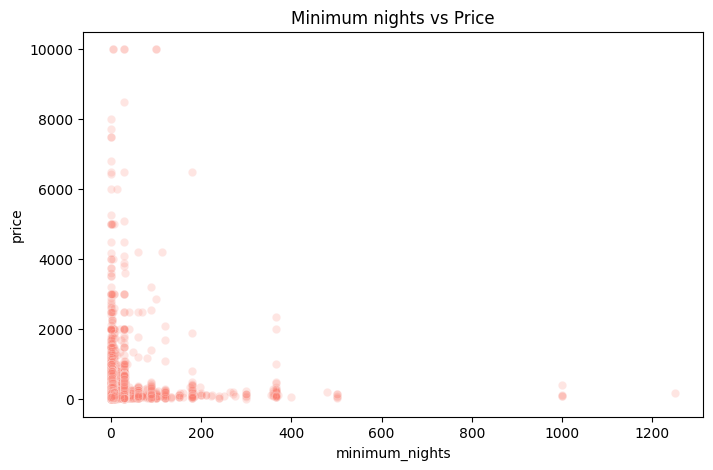

In [60]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="minimum_nights", y="price", alpha=0.2, color="salmon")
plt.title("Minimum nights vs Price")
plt.show()

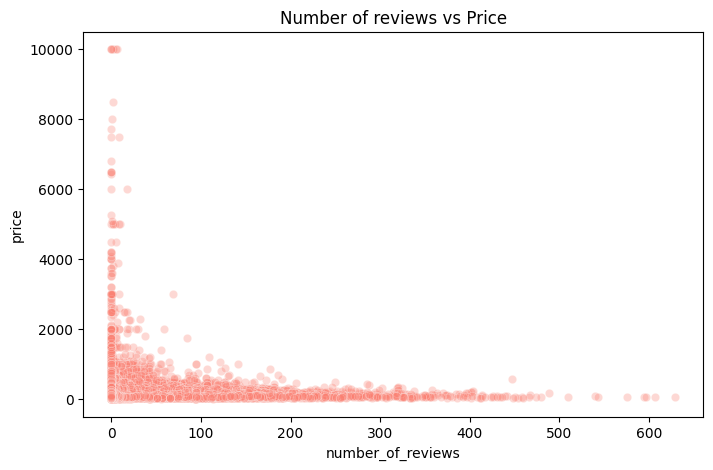

In [59]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="number_of_reviews", y="price", alpha=0.3, color="salmon")
plt.title("Number of reviews vs Price")
plt.show()

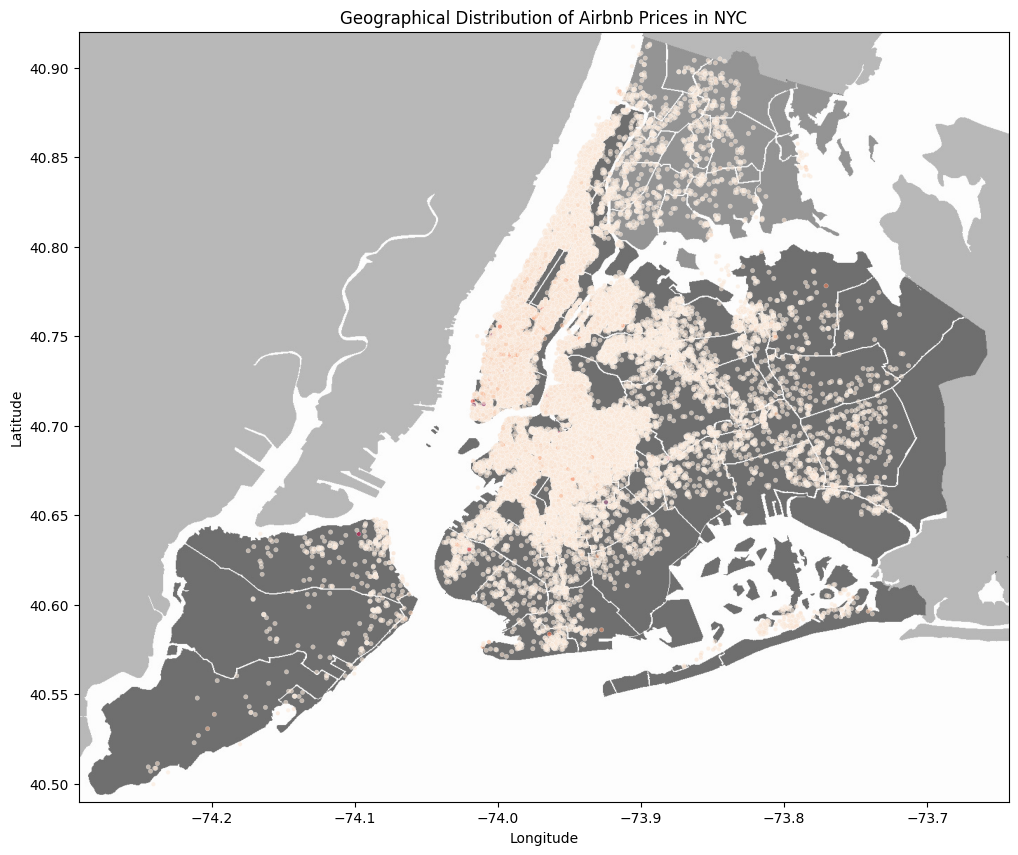

In [105]:
img = Image.open("New_York_City_.png")

plt.figure(figsize=(12,10))

plt.imshow(
    img,
    extent=[-74.293, -73.643, 40.49, 40.92],
    aspect="auto"
)

sns.scatterplot(
    data=df,
    x="longitude",
    y="latitude",
    hue="price",
    palette="rocket_r",
    alpha=0.6,
    s=10,
    legend=False
)

plt.title("Geographical Distribution of Airbnb Prices in NYC")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

#### Map Alignment Note

The borough map used as a background is a static PNG image and is not a fully geo-referenced basemap.  
Therefore, slight misalignment between the map borders and the real latitude/longitude coordinates may occur.  
The coordinate boundaries (`extent`) were manually tuned to achieve the best possible visual match.

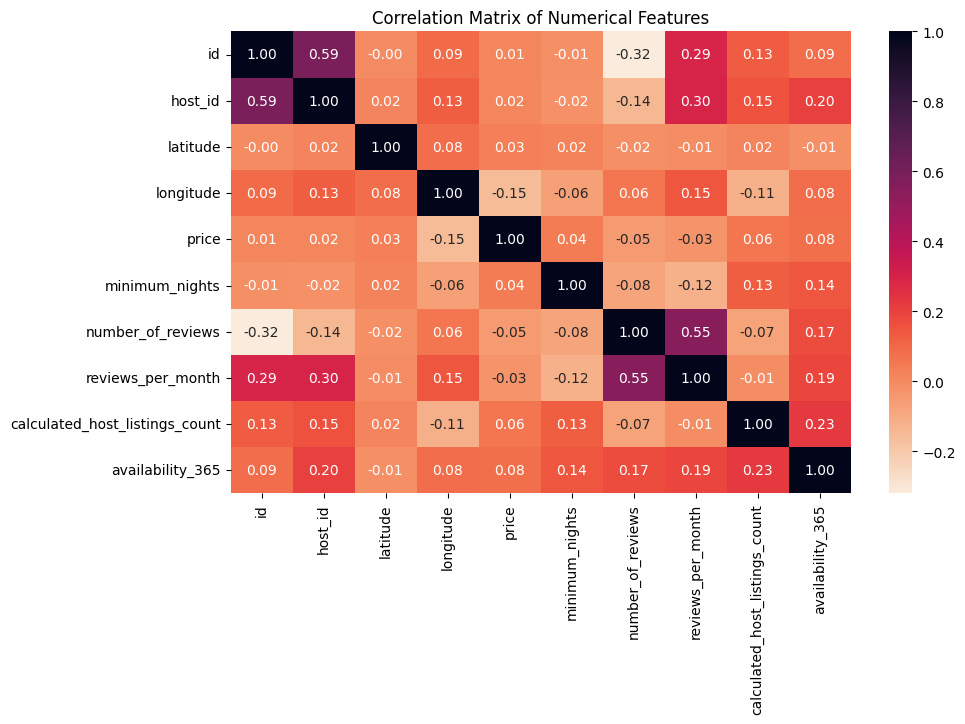

In [120]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="rocket_r",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()


The correlation matrix shows that most numerical variables have only weak linear relationships with price.  
This suggests that Airbnb pricing is influenced more strongly by categorical and location-based features (such as room type and neighbourhood group) rather than purely numerical counts.

#### Observations (Relationships between Features and Price)

- **Room type has a strong impact on price.**  
  Listings that offer an *entire home or apartment* are significantly more expensive on average than private or shared rooms.  
  Shared rooms represent the cheapest accommodation option.

- **Neighbourhood group is another key predictor of price.**  
  The highest median prices are observed in **Manhattan**, while boroughs such as **Bronx** and **Staten Island** tend to have much lower rental costs.  
  This confirms that location strongly influences Airbnb pricing.

- **Minimum nights shows a weak relationship with price.**  
  Most listings require short stays, and extremely high minimum-night values are rare outliers.  
  There is no clear linear dependency between minimum nights and price.

- **Number of reviews is negatively associated with price.**  
  Expensive listings tend to receive fewer reviews, while cheaper accommodations are reviewed more frequently.  
  This may reflect higher demand and higher booking frequency for affordable rentals.

- **Geographical distribution confirms spatial price patterns.**  
  Higher-priced listings are concentrated in central parts of the city (especially Manhattan), whereas outer areas contain more affordable options.


#### 1.6 Other EDA

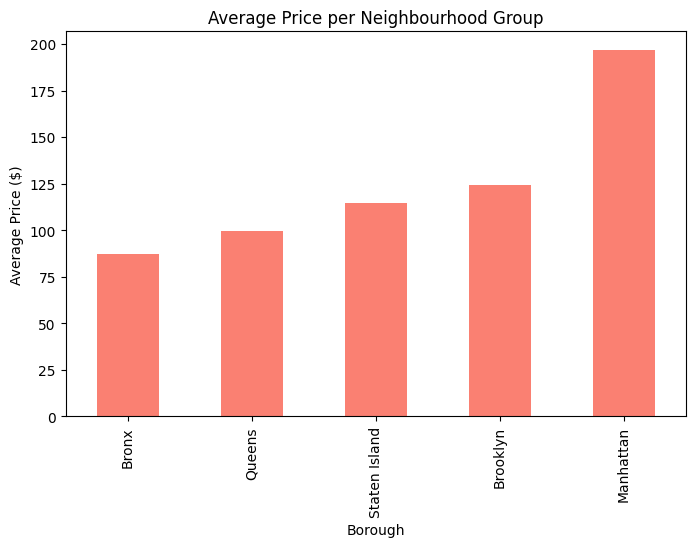

In [108]:
borough_price = df.groupby("neighbourhood_group")["price"].mean().sort_values()

plt.figure(figsize=(8,5))
borough_price.plot(kind="bar", color="salmon")

plt.title("Average Price per Neighbourhood Group")
plt.ylabel("Average Price ($)")
plt.xlabel("Borough")
plt.show()

Manhattan has the highest average rental price, while Bronx and Queens remain the most affordable boroughs.

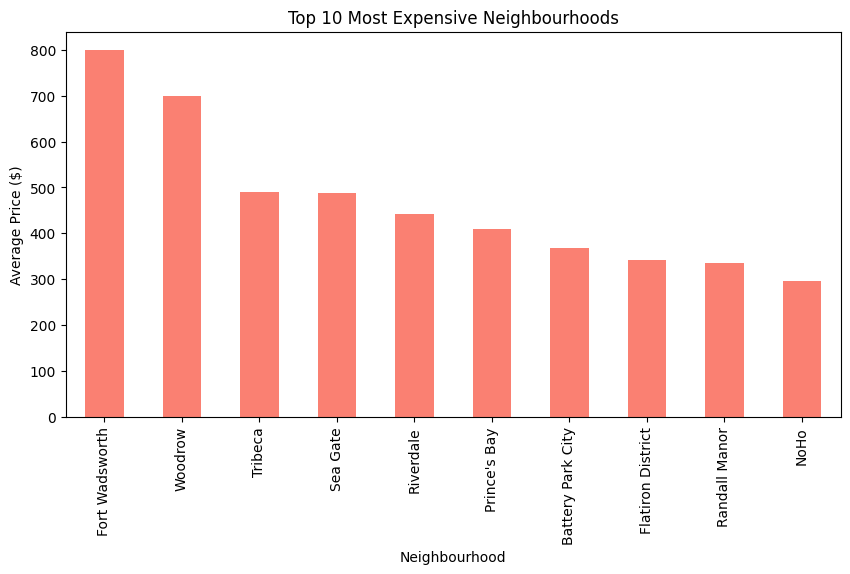

In [110]:
top_neigh = df.groupby("neighbourhood")["price"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_neigh.plot(kind="bar", color="salmon")

plt.title("Top 10 Most Expensive Neighbourhoods")
plt.ylabel("Average Price ($)")
plt.xlabel("Neighbourhood")
plt.show()


Some neighbourhoods are significantly more expensive, suggesting that finer location details are important for prediction.


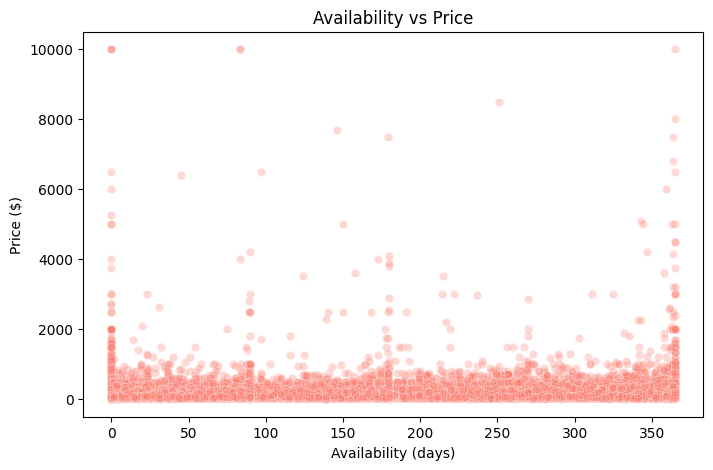

In [123]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="availability_365", y="price", alpha=0.3, color="salmon")

plt.title("Availability vs Price")
plt.ylabel("Price ($)")
plt.xlabel("Availability (days)")
plt.show()

Availability shows weak correlation with price.

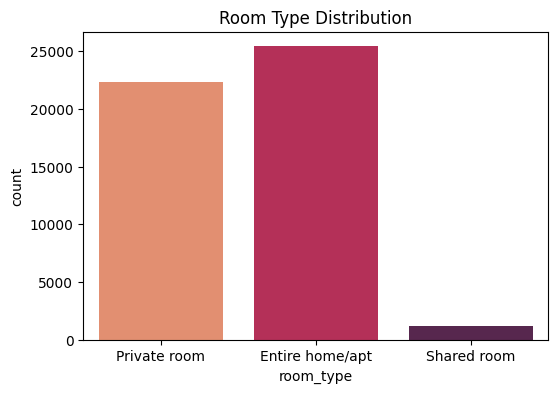

In [121]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x="room_type",
    hue="room_type",
    palette="rocket_r",
    legend=False
)

plt.title("Room Type Distribution")
plt.show()


Most Airbnb listings in NYC are either entire apartments or private rooms, while shared rooms are very rare.  
This indicates that shared accommodation is not a common option in the NYC rental market.


## 2. Data Preprocessing & Splitting

**Tasks:**
1. **Handle Missing Values**
2. **Feature Selection**
3. **Categorical Encoding**
4. **Outliers Handling**
5. **Data Splitting**

#### 2.1 Handling Missing Values

In [133]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

df = df.drop(columns=["last_review", "name", "host_name"])

KeyError: "['last_review', 'name', 'host_name'] not found in axis"

In [134]:
df.isnull().sum().sort_values(ascending=False).head(10)

id                     0
host_id                0
neighbourhood_group    0
neighbourhood          0
latitude               0
longitude              0
room_type              0
price                  0
minimum_nights         0
number_of_reviews      0
dtype: int64

The dataset contains missing values mainly in `reviews_per_month` and `last_review` (about 20.6%).  
Missing `reviews_per_month` indicates that a listing has no reviews, so these values were replaced with 0.

The feature `last_review` contains many missing values and represents a date, which requires additional processing and is not essential for price prediction. Therefore, it was removed.

The columns `name` and `host_name` have only a few missing values but are high-cardinality textual identifiers and were also excluded from the modeling dataset.


#### 2.2 Feature Selection

In [130]:
df_model = df[
    [
        "neighbourhood_group",
        "neighbourhood",
        "room_type",
        "latitude",
        "longitude",
        "minimum_nights",
        "number_of_reviews",
        "reviews_per_month",
        "calculated_host_listings_count",
        "availability_365",
        "price"
    ]
]

For price prediction, features that describe location, accommodation type, and listing activity were selected.  
Identifier columns such as `id` and `host_id` were not used because they do not provide predictive value.  

The final feature set includes categorical variables (`room_type`, neighbourhood information), geographical coordinates, and numerical characteristics such as minimum nights and availability.


#### 2.3 Categorical encoding

In [131]:
df_encoded = pd.get_dummies(
    df_model,
    columns=["neighbourhood_group", "neighbourhood", "room_type"],
    drop_first=True
)

In [132]:
df_encoded.shape

(48895, 234)

Categorical features were transformed into numerical format using One-Hot Encoding, allowing machine learning models to interpret location and room type categories.

The number of features increased significantly because the dataset contains many unique neighbourhood categories.  
This is expected and allows the model to capture detailed location effects on price.

#### 2.4 Outliers Handling & Target Transformation
The target variable `price` contains extreme outliers (up to $10,000), which may negatively affect regression performance.  

In [135]:
(df_encoded["price"] <= 0).sum()

np.int64(11)

In [136]:
df_encoded = df_encoded[df_encoded["price"] > 0].copy()

X = df_encoded.drop("price", axis=1)
y = np.log1p(df_encoded["price"])

A small number of listings (11 entries, less than 0.03% of the dataset) had non-positive values for the target variable `price`.  
Since price represents the rental cost per night, such values are not meaningful and likely correspond to data entry errors.

These observations were removed before applying the log-transformation.  
To reduce the influence of extreme high prices while preserving all valid listings, the target variable was transformed using `log1p(price)`.

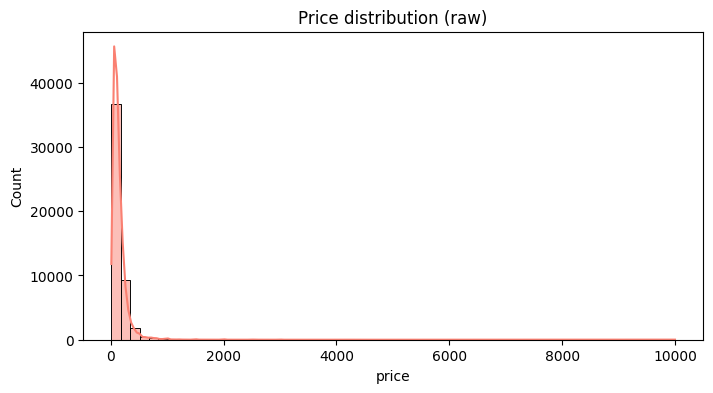

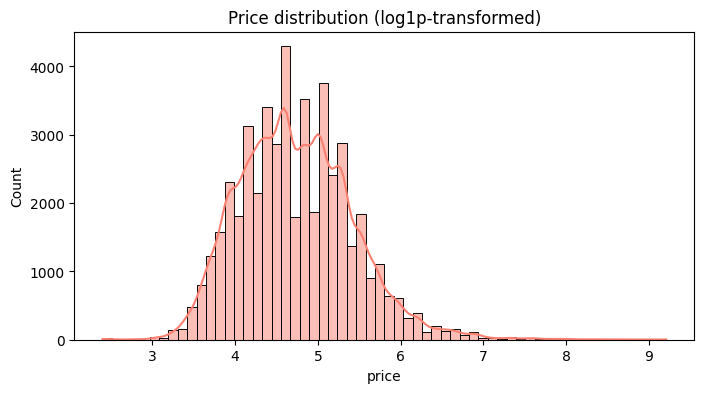

In [139]:
plt.figure(figsize=(8,4))
sns.histplot(df_encoded["price"], bins=60, kde=True, color="salmon")
plt.title("Price distribution (raw)")
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(y, bins=60, kde=True, color="salmon")
plt.title("Price distribution (log1p-transformed)")
plt.show()

The original price distribution is highly right-skewed, with most Airbnb listings concentrated at lower price values and a small number of extremely expensive listings reaching up to several thousand dollars.

Such extreme values create a long tail and can strongly affect regression models, especially those sensitive to outliers.

After applying the log1p transformation, the distribution becomes much more symmetric and closer to a normal shape.  
This transformation reduces the influence of very high prices while preserving all observations.

Therefore, `log1p(price)` was used as the target variable for model training to improve stability and predictive performance.

#### 2.5 Data splitting

In [141]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (39107, 233)
Test set: (9777, 233)


The dataset was split into training (80%) and testing (20%) subsets using `train_test_split`.  
This allows us to train models on one portion of the data and evaluate them on unseen listings.  
A fixed random seed ensures reproducibility.

## 3. Model Building

Initialize and training machine learning models suitable for this regression task.

In [144]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [145]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [146]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [153]:
gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

## 4. Evaluation & Analysis

**Tasks:**
1. Predict prices on the Test set for each model.
2. Calculate and compare evaluation metrics for each model. Choose metrics that are appropriate for this problem.
3. Analyze the results.

In [147]:
y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print(f"MAE:  {mae_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R²:   {r2_lr:.4f}")


Linear Regression Performance:
MAE:  0.3431
RMSE: 0.4777
R²:   0.5248


In [148]:
y_pred_dt = dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Performance:")
print(f"MAE:  {mae_dt:.4f}")
print(f"RMSE: {rmse_dt:.4f}")
print(f"R²:   {r2_dt:.4f}")


Decision Tree Performance:
MAE:  0.4326
RMSE: 0.6163
R²:   0.2092


In [149]:
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print(f"MAE:  {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²:   {r2_rf:.4f}")

Random Forest Performance:
MAE:  0.3139
RMSE: 0.4470
R²:   0.5838


In [154]:
y_pred_gbr = gbr_model.predict(X_test)

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting Performance:")
print(f"MAE:  {mae_gbr:.4f}")
print(f"RMSE: {rmse_gbr:.4f}")
print(f"R²:   {r2_gbr:.4f}")

Gradient Boosting Performance:
MAE:  0.3246
RMSE: 0.4540
R²:   0.5708


In [155]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "Gradient Boosting"],
    "MAE": [mae_lr, mae_dt, mae_rf, mae_gbr],
    "RMSE": [rmse_lr, rmse_dt, rmse_rf, rmse_gbr],
    "R2 Score": [r2_lr, r2_dt, r2_rf, r2_gbr]
})

results.sort_values(by="RMSE")

,Model,MAE,RMSE,R2 Score
2,Random Forest,0.313901,0.447048,0.583845
3,Gradient Boosting,0.324572,0.453986,0.570827
0,Linear Regression,0.343065,0.477728,0.524765
1,Decision Tree,0.432580,0.616251,0.209207


Four regression algorithms were trained and evaluated on the test set:

- Linear Regression (baseline)
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor 

Models were compared using MAE, RMSE, and R² on the test set.

Note: Evaluation metrics are computed on the log-transformed target variable (`log1p(price)`), which reduces sensitivity to extreme price values.

### Model Selection Logic
**Decision Tree Regressor** showed the weakest performance, likely due to overfitting and limited generalization ability when used as a single tree.

**Linear Regression** performed reasonably well as a baseline model, but its lower R² suggests that Airbnb pricing is not purely linear.

The **Random Forest Regressor** performed the best among the three models.

**Gradient Boosting** produced very similar results, slightly below Random Forest.  
  This further supports the importance of non-linear ensemble models for this dataset.

Random Forest Regressor achieved the lowest RMSE (0.447) and the highest R² score (0.584), indicating the strongest ability to explain price variation on unseen data.

This is expected because Random Forest is an ensemble of decision trees and can capture complex non-linear relationships between features such as location, room type, and availability.  
While Linear Regression assumes linearity and a single Decision Tree suffers from high variance, ensemble approaches like Random Forest and Gradient Boosting reduce these limitations through aggregation, resulting in superior predictive accuracy.


Therefore, Random Forest was selected as the most suitable model for this price prediction task.


In [156]:
y_pred_price = np.expm1(y_pred_rf)
y_test_price = np.expm1(y_test)
mae_dollars = mean_absolute_error(y_test_price, y_pred_price)

print("Random Forest MAE in dollars:", round(mae_dollars, 2))

Random Forest MAE in dollars: 56.34


## 5. Conclusion & Improvements

### Improvements

Although the Random Forest model achieved the best performance among the tested algorithms, there are several ways to further improve prediction accuracy:

- **Hyperparameter tuning**: Applying GridSearchCV or RandomizedSearchCV could optimize model parameters (tree depth, number of estimators, minimum samples, etc.).
- **More advanced algorithms**: Gradient Boosting variants such as XGBoost, LightGBM, or CatBoost often outperform basic ensembles on structured tabular data.
- **Feature engineering**: Creating new informative features (e.g., distance to city center, review activity ratios, host-level statistics) may improve predictive power.
- **Handling rare neighbourhood categories**: Reducing high-cardinality categorical variables or grouping infrequent neighbourhoods could help the model generalize better.
- **Incorporating additional data**: Amenities, textual descriptions, seasonal trends, and listing ratings are not included in the dataset but could significantly influence price.

---

### Practical Usage

This model can be applied in several real-world scenarios:

- **Pricing recommendations for hosts**: Airbnb hosts could use the model to estimate an appropriate rental price based on location, room type, and listing characteristics.
- **Market analysis for businesses**: Real estate companies or rental platforms could analyze pricing patterns across neighbourhoods and identify profitable areas.
- **Customer decision support**: Users searching for accommodation could compare predicted “fair prices” with actual listing prices to detect overpriced or undervalued offers.
- **Dynamic pricing systems**: Platforms could integrate such models into automated pricing tools that adjust rates depending on demand and availability.

Overall, predictive models like this can support more data-driven decision-making in the short-term rental market.
